In [1]:
import autofile

In [2]:
# scan_prefix = "/lcrc/project/PACC/copan/amech-dev/work/project-cyclopentane/save/RXN/C5H7.H2/JPHNWLRCPAANFZ/0_0/2_1/UHFFFAOYSA-N/C5H8.H/HXSUBTKPGKLJOF/0_0/1_2/UHFFFAOYSA-N/2/u-unGOU/TS/00/Z/00/"
scan_prefix = "/lcrc/project/PACC/copan/amech-dev/work/project-cyclopentane/save/RXN/C5H7.H2/JPHNWLRCPAANFZ/0_0/2_1/UHFFFAOYSA-N/C5H8.H/HXSUBTKPGKLJOF/0_0/1_2/UHFFFAOYSA-N/2/u-unGOU/TS/00/Z/00/"

coo_loc = ["R3"]
ene_loc = ["wb97xd", "def2-svp", "U"]

In [7]:
scan_fs = autofile.fs.scan(scan_prefix)
locs = [L for L in scan_fs[-1].existing() if L[0] == coo_loc]
locs

[[['R3'], [2.2487740892948156]],
 [['R3'], [2.4917388768536792]],
 [['R3'], [2.734703664412543]],
 [['R3'], [2.9776684519714065]],
 [['R3'], [3.22063323953027]],
 [['R3'], [3.463598027089134]],
 [['R3'], [3.7065628146479974]],
 [['R3'], [3.949527602206861]]]

In [10]:
import automol

# geo = scan_fs[-1].file.geometry.read(min(locs))
geo = scan_fs[-1].file.geometry.read([['R3'], [2.9776684519714065]])
automol.geom.display(geo)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [5]:
geo = scan_fs[-1].file.geometry.read(max(locs))
automol.geom.display(geo)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

[1.1896014932369574, 1.3181298658555964, 1.4466582384742352, 1.575186611092874, 1.703714983711513, 1.832243356330152, 1.9607717289487907, 2.0893001015674297]
[-195.623075752, -195.604604718, -195.601305285, -195.601159389, -195.602319465, -195.603750152, -195.605010844, -195.605928308]


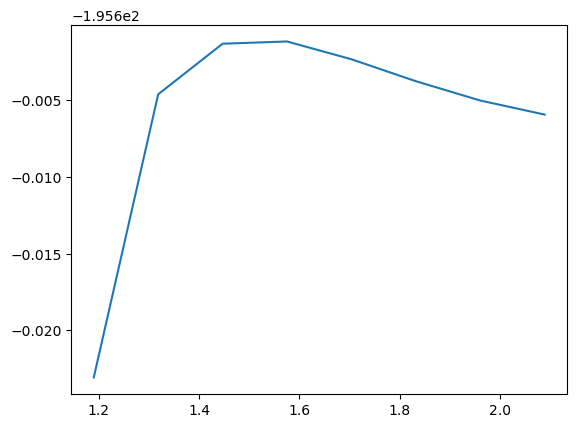

In [6]:

dists = []
enes = []
for locs in locs:
    # Get the distance
    *_, (dist,) = locs
    dists.append(dist * 0.529)

    # Get the energy
    scan_path = scan_fs[-1].path(locs)
    sp_fs = autofile.fs.single_point(scan_path)
    ene = sp_fs[-1].file.energy.read(ene_loc)
    enes.append(ene)
print(dists)
print(enes)

# dists.insert(1, 1.3083)
# enes.insert(1, -691.992853512)

from matplotlib import pyplot

pyplot.plot(dists, enes)
pyplot.show()